In [1]:
import keras_ocr
import matplotlib.pyplot as plt
import pandas as pd
from utils import draw_sequence
import cv2
import numpy as np
import os
import string

2025-03-19 17:11:21.403833: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-19 17:11:21.434103: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-19 17:11:21.861788: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
image_path = "./data/feature1.jpg"
out_dir = "./out"

## 加载模型

In [3]:
# weights_dir = '/Users/ywu/develop/projects/boze/AI/keras-ocr/train/'
weights_dir = '/home/linkedata/projects/ai/keras-ocr/train/'
# weights_file_name = 'recognizer_borndigital.h5'
# weights_file_name = 'recognizer_2025-03-19T15:22:23.118003.h5'
weights_file_name = 'recognizer_epochs-100_2025-03-19T16:08:59.461013.h5'

alphabet = string.digits + string.ascii_letters + '+-×±Φφ. '
recognizer_alphabet = ''.join(sorted(set(alphabet)))

# 这里Recognizer使用的alphabet需要和Finetune中的alphabet相同, 不然会报tensor shape mismatch错误
recognizer = keras_ocr.recognition.Recognizer(alphabet=recognizer_alphabet)
weights_path = os.path.join(weights_dir, weights_file_name)
recognizer.model.load_weights(weights_path)
pipeline = keras_ocr.pipeline.Pipeline(recognizer=recognizer)

2025-03-19 17:11:29.015000: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-19 17:11:29.034129: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-19 17:11:29.034262: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Provided alphabet does not match pretrained alphabet. Using backbone weights only.
Looking for /home/linkedata/.keras-ocr/crnn_kurapan_notop.h5
Looking for /home/linkedata/.keras-ocr/craft_mlt_25k.h5


## 图片处理

In [4]:
img = cv2.imread(image_path)
sharpening_filter = np.array([[-1,-1,-1],[-1,9,-1],[-1,-1,-1]])
sharpened_image= cv2.filter2D(img,-1,sharpening_filter)

## 检测

In [5]:
results = pipeline.recognize([sharpened_image])
df = pd.DataFrame(results[0],columns=["Text","Bounding_Boxes"])
Bounding_boxes = df["Bounding_Boxes"].values

2025-03-19 17:11:36.189158: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2025-03-19 17:11:36.242083: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-03-19 17:11:37.690811: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


2/2 [==============================] - 1s 78ms/step


## 展示

<Axes: >

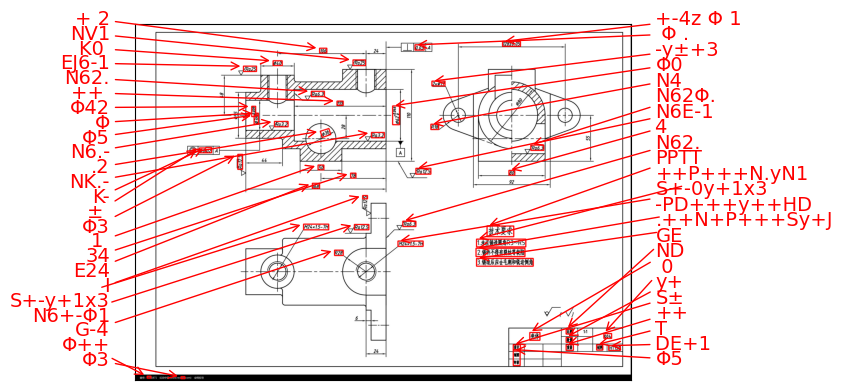

In [6]:
# 画标注
keras_ocr.tools.drawAnnotations(image=img, predictions=results[0])

[(1, '+-4z Φ 1'), (2, ' Φ .'), (3, '+ 2'), (4, 'NV1'), (5, 'K0 '), (6, 'EJ6-1'), (7, '-y±+3'), (8, 'N62.'), (9, '++ '), (10, 'Φ0'), (11, 'Φ42'), (12, 'Φ'), (13, 'Φ5'), (14, 'N6.-'), (15, 'N4'), (16, '.2'), (17, 'NK.-'), (18, 'N62Φ.'), (19, 'K-'), (20, '± '), (21, 'Φ3'), (22, '1 '), (23, 'N6E-1'), (24, '4 '), (25, '34'), (26, 'E24'), (27, 'I'), (28, 'N62.'), (29, 'S+-y+1x3'), (30, 'N6+-Φ1'), (31, 'PPTT'), (32, '++P+++N.yN1'), (33, 'S+-0y+1x3'), (34, '-PD+++y++HD'), (35, 'G-4'), (36, '.++N+P+++Sy+J'), (37, 'GE'), (38, 'ND'), (39, ' 0'), (40, 'y+'), (41, 'S±'), (42, '++'), (43, 'T'), (44, 'DE+1 '), (45, 'Φ5'), (46, 'Φ++'), (47, 'Φ3')]


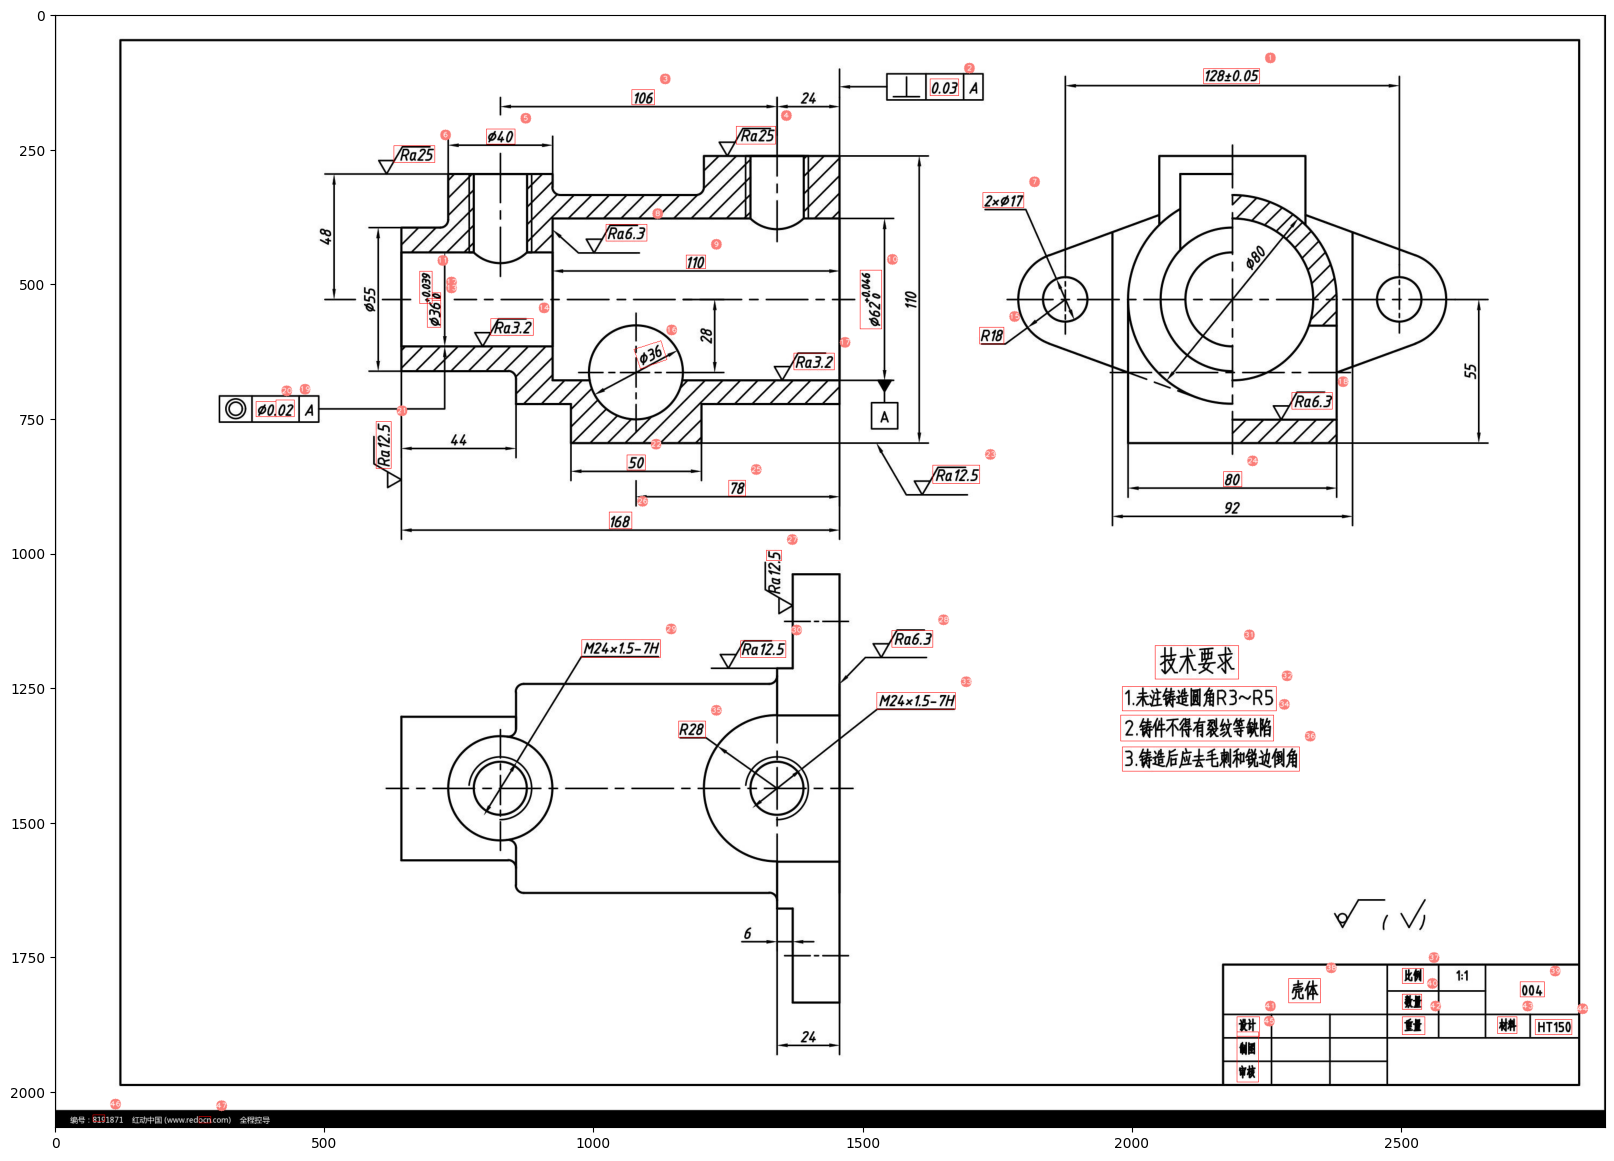

In [7]:
# 画气泡图
plt.figure(figsize = (20,20))

# 画框
canvas = keras_ocr.tools.drawBoxes(plt.imread(image_path),Bounding_boxes,thickness=1)

# 画标注
Text = df["Text"].values
test_seq = draw_sequence(Text, Bounding_boxes, canvas)

canvas_save = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
cv2.imwrite(f'{out_dir}/feature1_result3.png', canvas_save)

print(test_seq)

plt.imshow(canvas)

# plt.show()